In [37]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

cwd = Path.cwd()
root = None
for p in [cwd] + list(cwd.parents):
    if (p / "data").exists() and (p / "reports").exists():
        root = p
        break

if root is None:
    raise FileNotFoundError(f"Could not locate repo root from cwd={cwd}")

print("Repo root:", root)

tsv = root / "reports" / "external_test_spades_results.tsv"
if not tsv.exists():
    raise FileNotFoundError(f"Missing file: {tsv}")

print("Loading TSV:", tsv)

df = pd.read_csv(tsv, sep="\t")
df.head()

Repo root: /Users/yvonnelin/Desktop/mitochime
Loading TSV: /Users/yvonnelin/Desktop/mitochime/reports/external_test_spades_results.tsv


,dataset,filter,reads_pairs_unfiltered,reads_pairs_filtered,reads_kept_pct,contigs_unfiltered,contigs_filtered,bp_unfiltered,bp_filtered,delta_bp,...,N50_filtered,delta_N50,max_unfiltered,max_filtered,delta_max,nodes_unfiltered,nodes_filtered,edges_unfiltered,edges_filtered,run_root
0,10K_final_10,bigru,NaN,NaN,NaN,1,1,16704,16614,-90,...,16614,-90,16704,16614,-90,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
1,10K_final_10,cnn,NaN,NaN,NaN,1,1,16704,16693,-11,...,16693,-11,16704,16693,-11,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
2,10K_final_10,gb,NaN,NaN,NaN,1,1,16704,16614,-90,...,16614,-90,16704,16614,-90,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
3,10K_final_15,bigru,NaN,NaN,NaN,1,1,16735,16611,-124,...,16611,-124,16735,16611,-124,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
4,10K_final_15,cnn,NaN,NaN,NaN,1,1,16735,16611,-124,...,16611,-124,16735,16611,-124,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...


In [38]:
def parse_read_level(s: str):
    m = re.match(r"^(3200|10K|20K)", str(s))
    return m.group(1) if m else None

def parse_chimera_pct(s: str):
    m = re.search(r"_final_(\d+)", str(s))
    return int(m.group(1)) if m else None

df["read_level"] = df["dataset"].apply(parse_read_level)
df["chimera_pct"] = df["dataset"].apply(parse_chimera_pct)

order = ["3200", "10K", "20K"]
df["read_level"] = pd.Categorical(df["read_level"], order, ordered=True)

df[["dataset", "read_level", "chimera_pct", "filter", "reads_kept_pct"]].sort_values(
    ["read_level", "chimera_pct", "filter"]
).head(20)

,dataset,read_level,chimera_pct,filter,reads_kept_pct
30,3200_final_5,3200,5,bigru,NaN
31,3200_final_5,3200,5,cnn,NaN
32,3200_final_5,3200,5,gb,NaN
24,3200_final_10,3200,10,bigru,NaN
25,3200_final_10,3200,10,cnn,NaN
26,3200_final_10,3200,10,gb,NaN
27,3200_final_15,3200,15,bigru,NaN
28,3200_final_15,3200,15,cnn,NaN
29,3200_final_15,3200,15,gb,NaN
33,3200_final_50,3200,50,bigru,NaN


In [39]:
print("Filter counts:")
print(df["filter"].value_counts(dropna=False))

print("\nDataset x filter counts:")
display(
    df.groupby(["dataset", "filter"]).size().unstack(fill_value=0).sort_index()
)

Filter counts:
filter
bigru    12
cnn      12
gb       12
Name: count, dtype: int64

Dataset x filter counts:


filter,bigru,cnn,gb
dataset,,,
10K_final_10,1,1,1
10K_final_15,1,1,1
10K_final_5,1,1,1
10K_final_50,1,1,1
20K_final_10,1,1,1
20K_final_15,1,1,1
20K_final_5,1,1,1
20K_final_50,1,1,1
3200_final_10,1,1,1


In [40]:
final_tbl = df[[
    "read_level",
    "chimera_pct",
    "dataset",
    "filter",
    "reads_pairs_unfiltered",
    "reads_pairs_filtered",
    "reads_kept_pct",
    "contigs_unfiltered",
    "contigs_filtered",
    "bp_unfiltered",
    "bp_filtered",
    "delta_bp",
    "N50_unfiltered",
    "N50_filtered",
    "delta_N50",
    "max_unfiltered",
    "max_filtered",
    "delta_max",
    "nodes_unfiltered",
    "nodes_filtered",
    "edges_unfiltered",
    "edges_filtered",
    "run_root",
]].sort_values(["read_level", "chimera_pct", "filter"]).reset_index(drop=True)

final_tbl

,read_level,chimera_pct,dataset,filter,reads_pairs_unfiltered,reads_pairs_filtered,reads_kept_pct,contigs_unfiltered,contigs_filtered,bp_unfiltered,...,N50_filtered,delta_N50,max_unfiltered,max_filtered,delta_max,nodes_unfiltered,nodes_filtered,edges_unfiltered,edges_filtered,run_root
0,3200,5,3200_final_5,bigru,NaN,NaN,NaN,1,1,16599,...,16315,-284,16599,16315,-284,2,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
1,3200,5,3200_final_5,cnn,NaN,NaN,NaN,1,1,16599,...,16575,-24,16599,16575,-24,2,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
2,3200,5,3200_final_5,gb,NaN,NaN,NaN,1,1,16599,...,16577,-22,16599,16577,-22,2,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
3,3200,10,3200_final_10,bigru,NaN,NaN,NaN,1,1,16591,...,16419,-172,16591,16419,-172,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
4,3200,10,3200_final_10,cnn,NaN,NaN,NaN,1,1,16591,...,16590,-1,16591,16590,-1,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
5,3200,10,3200_final_10,gb,NaN,NaN,NaN,1,1,16591,...,16615,24,16591,16615,24,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
6,3200,15,3200_final_15,bigru,NaN,NaN,NaN,1,1,16645,...,16562,-83,16645,16562,-83,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
7,3200,15,3200_final_15,cnn,NaN,NaN,NaN,1,2,16645,...,14925,-1720,16645,14925,-1720,1,3,0,2,/Users/yvonnelin/Desktop/mitochime/data/assemb...
8,3200,15,3200_final_15,gb,NaN,NaN,NaN,1,1,16645,...,16606,-39,16645,16606,-39,1,1,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...
9,3200,50,3200_final_50,bigru,NaN,NaN,NaN,1,8,16736,...,3984,-12752,16736,7466,-9270,1,8,0,0,/Users/yvonnelin/Desktop/mitochime/data/assemb...


In [41]:
cand = df[df["filter"].isin(["gb", "cnn", "bigru"])].copy()

best = (
    cand.sort_values(
        ["dataset", "nodes_filtered", "edges_filtered", "contigs_filtered", "max_filtered", "reads_kept_pct"],
        ascending=[True, True, True, True, False, False]
    )
    .groupby("dataset", as_index=False)
    .head(1)
    .sort_values(["read_level", "chimera_pct"])
)

best[[
    "read_level",
    "chimera_pct",
    "dataset",
    "filter",
    "reads_kept_pct",
    "contigs_filtered",
    "bp_filtered",
    "N50_filtered",
    "max_filtered",
    "nodes_filtered",
    "edges_filtered",
    "delta_bp",
    "delta_N50",
    "delta_max",
]]

,read_level,chimera_pct,dataset,filter,reads_kept_pct,contigs_filtered,bp_filtered,N50_filtered,max_filtered,nodes_filtered,edges_filtered,delta_bp,delta_N50,delta_max
32,3200,5,3200_final_5,gb,NaN,1,16577,16577,16577,1,0,-22,-22,-22
26,3200,10,3200_final_10,gb,NaN,1,16615,16615,16615,1,0,24,24,24
29,3200,15,3200_final_15,gb,NaN,1,16606,16606,16606,1,0,-39,-39,-39
35,3200,50,3200_final_50,gb,NaN,1,16646,16646,16646,1,0,-90,-90,-90
8,10K,5,10K_final_5,gb,NaN,1,16615,16615,16615,1,0,0,0,0
1,10K,10,10K_final_10,cnn,NaN,1,16693,16693,16693,1,0,-11,-11,-11
5,10K,15,10K_final_15,gb,NaN,1,16642,16642,16642,1,0,-93,-93,-93
9,10K,50,10K_final_50,bigru,NaN,1,16590,16590,16590,2,0,-125,-125,-125
19,20K,5,20K_final_5,cnn,NaN,1,16669,16669,16669,1,0,0,0,0
12,20K,10,20K_final_10,bigru,NaN,1,16698,16698,16698,1,0,-101,-101,-101


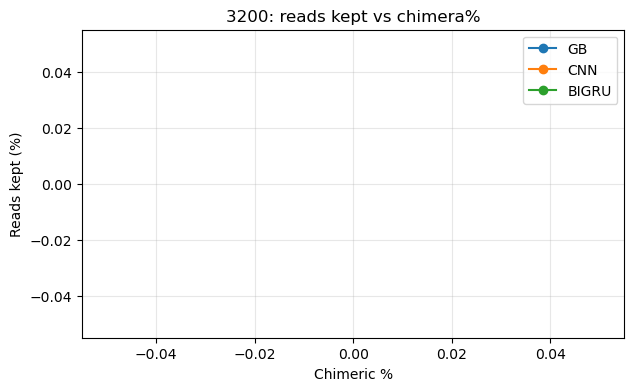

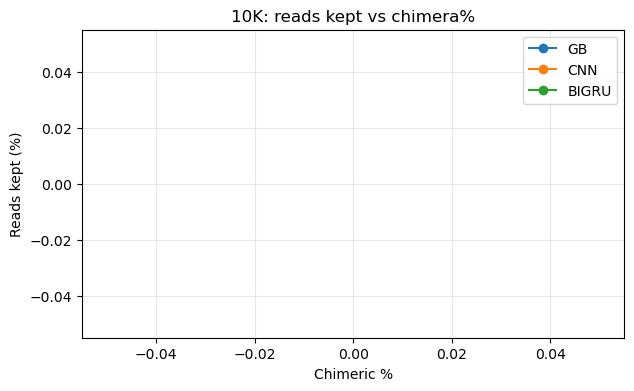

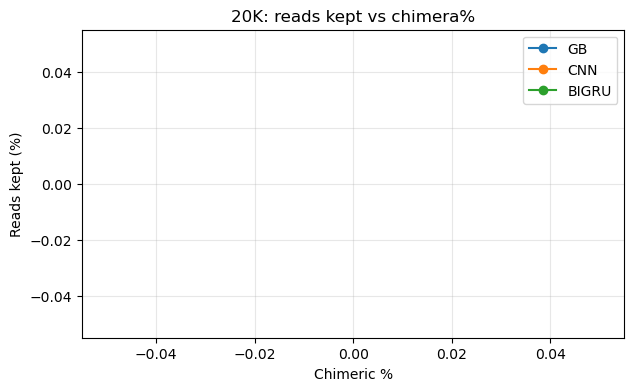

In [42]:
plot_df = df.copy()
model_order = ["gb", "cnn", "bigru"]

for rl in ["3200", "10K", "20K"]:
    d = plot_df[plot_df["read_level"] == rl].sort_values("chimera_pct")
    if d.empty:
        continue

    plt.figure(figsize=(7, 4))
    for m in model_order:
        dm = d[d["filter"] == m]
        if dm.empty:
            continue
        plt.plot(dm["chimera_pct"], dm["reads_kept_pct"], marker="o", label=m.upper())

    plt.xlabel("Chimeric %")
    plt.ylabel("Reads kept (%)")
    plt.title(f"{rl}: reads kept vs chimera%")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

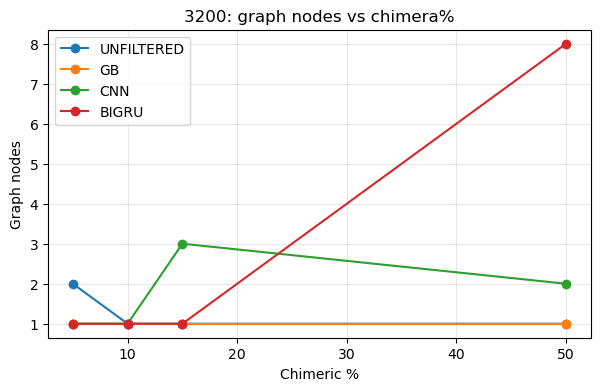

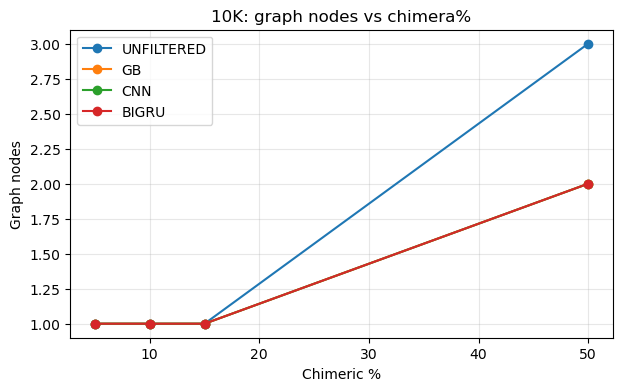

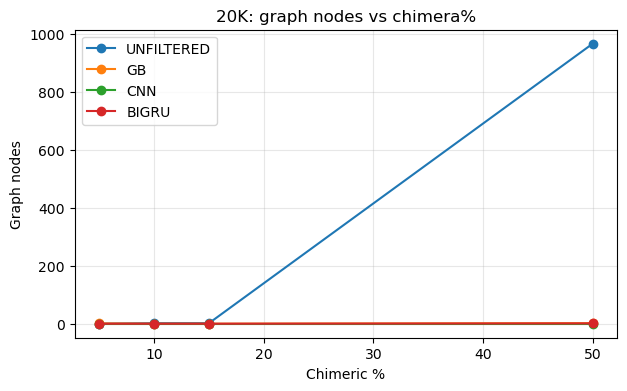

In [43]:
for rl in ["3200", "10K", "20K"]:
    d = plot_df[plot_df["read_level"] == rl].sort_values("chimera_pct")
    if d.empty:
        continue

    plt.figure(figsize=(7, 4))
    plt.plot(
        d.drop_duplicates("dataset")["chimera_pct"],
        d.drop_duplicates("dataset")["nodes_unfiltered"],
        marker="o",
        label="UNFILTERED"
    )

    for m in model_order:
        dm = d[d["filter"] == m]
        if dm.empty:
            continue
        plt.plot(dm["chimera_pct"], dm["nodes_filtered"], marker="o", label=m.upper())

    plt.xlabel("Chimeric %")
    plt.ylabel("Graph nodes")
    plt.title(f"{rl}: graph nodes vs chimera%")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

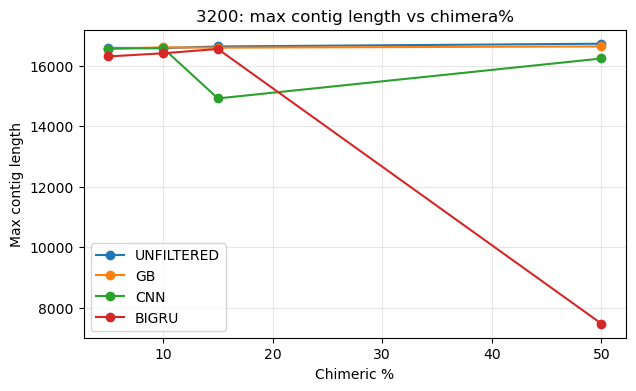

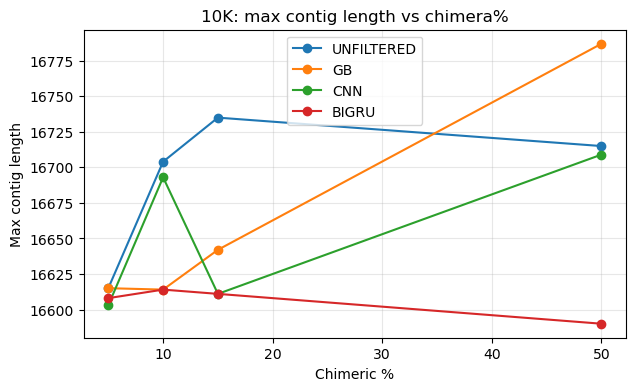

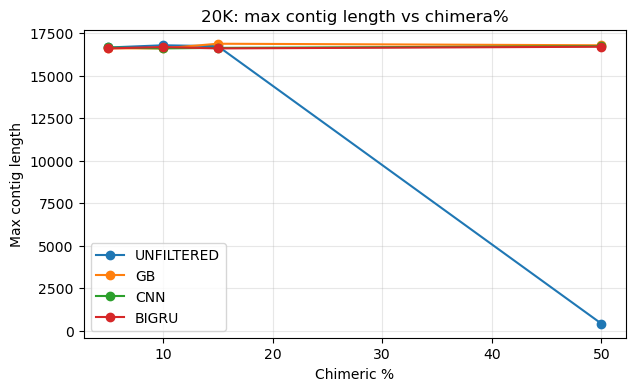

In [44]:
for rl in ["3200", "10K", "20K"]:
    d = plot_df[plot_df["read_level"] == rl].sort_values("chimera_pct")
    if d.empty:
        continue

    plt.figure(figsize=(7, 4))
    plt.plot(
        d.drop_duplicates("dataset")["chimera_pct"],
        d.drop_duplicates("dataset")["max_unfiltered"],
        marker="o",
        label="UNFILTERED"
    )

    for m in model_order:
        dm = d[d["filter"] == m]
        if dm.empty:
            continue
        plt.plot(dm["chimera_pct"], dm["max_filtered"], marker="o", label=m.upper())

    plt.xlabel("Chimeric %")
    plt.ylabel("Max contig length")
    plt.title(f"{rl}: max contig length vs chimera%")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

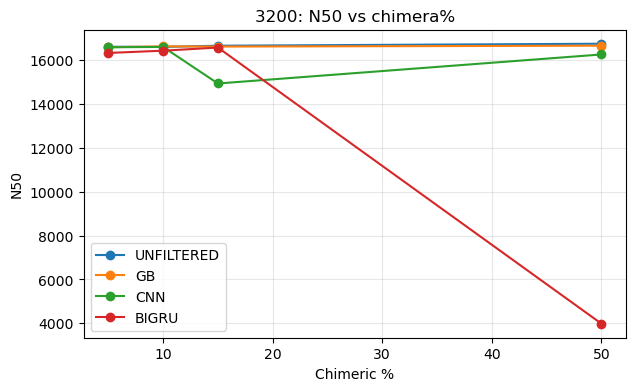

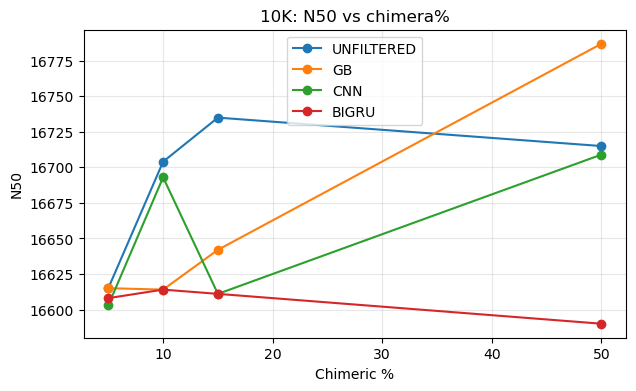

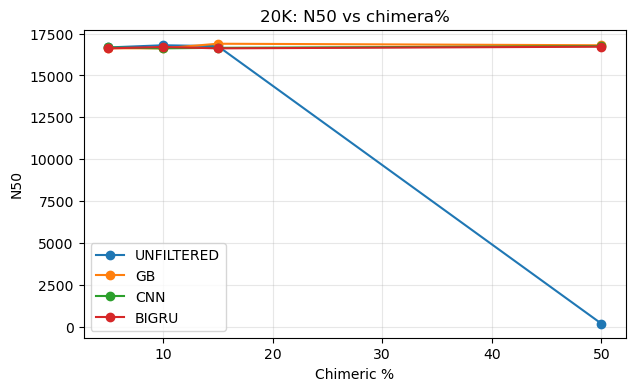

In [45]:
for rl in ["3200", "10K", "20K"]:
    d = plot_df[plot_df["read_level"] == rl].sort_values("chimera_pct")
    if d.empty:
        continue

    plt.figure(figsize=(7, 4))
    plt.plot(
        d.drop_duplicates("dataset")["chimera_pct"],
        d.drop_duplicates("dataset")["N50_unfiltered"],
        marker="o",
        label="UNFILTERED"
    )

    for m in model_order:
        dm = d[d["filter"] == m]
        if dm.empty:
            continue
        plt.plot(dm["chimera_pct"], dm["N50_filtered"], marker="o", label=m.upper())

    plt.xlabel("Chimeric %")
    plt.ylabel("N50")
    plt.title(f"{rl}: N50 vs chimera%")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [46]:
out_dir = root / "reports"

final_tbl.to_csv(out_dir / "final_metrics_external_test.tsv", sep="\t", index=False)
best.to_csv(out_dir / "final_best_per_dataset_external_test.tsv", sep="\t", index=False)

print("Wrote:")
print("-", out_dir / "final_metrics_external_test.tsv")
print("-", out_dir / "final_best_per_dataset_external_test.tsv")

Wrote:
- /Users/yvonnelin/Desktop/mitochime/reports/final_metrics_external_test.tsv
- /Users/yvonnelin/Desktop/mitochime/reports/final_best_per_dataset_external_test.tsv
